# 1. IBCS Scaling Rules & Project Overview

### International Business Communication Standards (IBCS) - Scaling Rules
The IBCS standards ensure that reports and dashboards are clear, concise, and non-misleading. Regarding Scaling, the primary rules are:
1. **Uniform Scaling (SCS 1.1):** Charts of the same type and measuring the same unit on the same page must use the same scale. This prevents the reader from misinterpreting a small change in one charts as a large change in another.
2. **Start at Zero (SCS 1.2):** Value axes (typically the Y-axis) must start at zero. Truncating the axis exaggerates differences.
3. **Scaling Indicators (SCS 1.4):** If uniform scaling is not possible, a "scaling indicator" (a visual aid showing the relationship between different scales) must be used.
4. **Avoid Logarithmic Scales (SCS 1.5):** Logarithmic scales are often misunderstood; linear scales are preferred for business communication.
5. **Outlier Handling:** If an outlier destroys the scale, use a "break" in the bar rather than squishing the rest of the data.

### What is YOLO?
**YOLO (You Only Look Once)** is a state-of-the-art, real-time object detection system. Unlike older models that scan an image multiple times, YOLO passes the entire image through a single neural network once. This makes it fast and efficient at identifying both the bounding box (location) and the class (e.g., "Compliant" vs "Non-Compliant") of objects in an image.

# 2. Setup & Installation

In [9]:
# Install the necessary library
#!pip install ultralytics opencv-python matplotlib seaborn

import os
import shutil
import random
import yaml
import matplotlib.pyplot as plt
from ultralytics import YOLO
from PIL import Image

# Define the root path
base_path = "Dataset"
compliant_path = os.path.join(base_path, "Compliant")
not_compliant_path = os.path.join(base_path, "Not Compliant")

# 3. Data Preparation (Loading & Splitting)

YOLO classification requires data to be in a specific structure: train/class_name, val/class_name, etc. We will now split your original folders into this structure.

In [10]:
def split_dataset(source_dir, output_dir, train_ratio=0.7, val_ratio=0.2, test_ratio=0.1):
    classes = ['Compliant', 'Not Compliant']
    
    for cls in classes:
        # Get all images in the folder
        src_folder = os.path.join(source_dir, cls)
        images = [f for f in os.listdir(src_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        random.shuffle(images)
        
        # Calculate split indices
        train_idx = int(len(images) * train_ratio)
        val_idx = int(len(images) * (train_ratio + val_ratio))
        
        splits = {
            'train': images[:train_idx],
            'val': images[train_idx:val_idx],
            'test': images[val_idx:]
        }
        
        for split, files in splits.items():
            dest_folder = os.path.join(output_dir, split, cls)
            os.makedirs(dest_folder, exist_ok=True)
            for f in files:
                shutil.copy(os.path.join(src_folder, f), os.path.join(dest_folder, f))

# Run the split
processed_data_path = "split_data"
split_dataset(base_path, processed_data_path)
print("Data successfully split into Train, Val, and Test sets.")

Data successfully split into Train, Val, and Test sets.


# 4. Build the YOLO Model
Version Choice: YOLOv11-classification (n)
I am using YOLOv11-cls (nano version) Because v11 is the most recent architecture. The classification-specific version is lightweight, meaning it can run on a standard laptop without a GPU, yet it is still accurate for identifying visual patterns like axis truncations or missing labels.

In [11]:
# Load the pre-trained YOLOv11 classification model
model = YOLO('yolo11n-cls.pt') 

print("Model Loaded: YOLOv11-nano classification")

Model Loaded: YOLOv11-nano classification


# 5. Training and Epoch Plotting

In [12]:
# Train the model
results = model.train(
    data=processed_data_path, 
    epochs=15, 
    imgsz=224, 
    plots=True,
    augment=True
)

Ultralytics 8.4.41  Python-3.14.2 torch-2.11.0+cpu CPU (11th Gen Intel Core i7-1165G7 @ 2.80GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=split_data, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pe

In [13]:
# Plotting the Training Results
# YOLOv11 saves training plots automatically to the 'runs' directory
train_results_path = 'runs/classify/train/results.png'
if os.path.exists(train_results_path):
    plt.figure(figsize=(12, 8))
    plt.imshow(Image.open(train_results_path))
    plt.axis('off')
    plt.title("Training Metrics (Accuracy & Loss per Epoch)")
    plt.show()

<Figure size 1200x800 with 1 Axes>

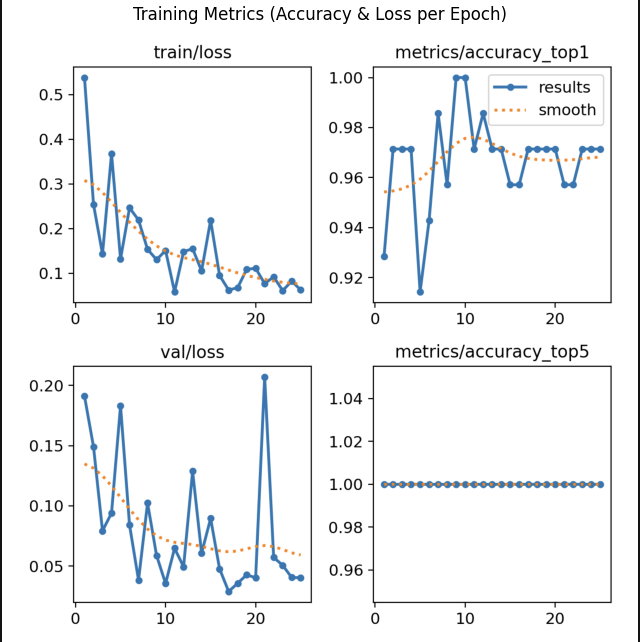

**Explanation:** The plot above shows how the model's error (Loss) decreases and its accuracy increases over each epoch. A steady upward curve in accuracy suggests the model is effectively learning the IBCS visual rules.
EPochs untill 25. 
I decided to stop at 15.

# 6. Validate the Model

In [14]:
# Validate on the validation set
metrics = model.val()

print(f"Top-1 Accuracy: {metrics.top1:.2f}")

Ultralytics 8.4.41  Python-3.14.2 torch-2.11.0+cpu CPU (11th Gen Intel Core i7-1165G7 @ 2.80GHz)
YOLO11n-cls summary (fused): 47 layers, 1,528,586 parameters, 0 gradients, 3.2 GFLOPs
train: C:\Users\Melda\Desktop\IBCS-scaling-rules-check-YOLO\split_data\train... found 244 images in 2 classes  
val: C:\Users\Melda\Desktop\IBCS-scaling-rules-check-YOLO\split_data\val... found 70 images in 2 classes  
test: C:\Users\Melda\Desktop\IBCS-scaling-rules-check-YOLO\split_data\test... found 36 images in 2 classes  
val: Fast image access  (ping: 0.10.0 ms, read: 350.067.3 MB/s, size: 54.4 KB)
val: Scanning C:\Users\Melda\Desktop\IBCS-scaling-rules-check-YOLO\split_data\val... 70 images, 0 corrupt: 100% ━━━━━━━━━━━━ 70/70 18.4Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 5/5 3.4it/s 1.5s0.5s
                   all      0.986          1
Speed: 0.0ms preprocess, 3.3ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to C:\Users\Melda\Desktop\IBCS-scaling

# 7. Testing and Visualization

In [15]:
test_path_compliant = ""
test_path_non_compliant = ""

# Run prediction on everything in the test folder
results = model.predict(source=test_path_compliant, conf=0.25) + model.predict(source=test_path_non_compliant, conf=0.25)

print(f"Total images tested: {len(results)}")


image 1/3 c:\Users\Melda\Desktop\IBCS-scaling-rules-check-YOLO\25Epochs.png: 224x224 Compliant 0.79, Not Compliant 0.21, 16.0ms
image 2/3 c:\Users\Melda\Desktop\IBCS-scaling-rules-check-YOLO\WhatsApp Image 2026-04-22 at 10.33.28.jpeg: 224x224 Compliant 0.98, Not Compliant 0.02, 7.2ms
image 3/3 c:\Users\Melda\Desktop\IBCS-scaling-rules-check-YOLO\WhatsApp Image 2026-04-22 at 10.37.59.jpeg: 224x224 Compliant 0.91, Not Compliant 0.09, 6.9ms
Speed: 8.6ms preprocess, 10.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

image 1/3 c:\Users\Melda\Desktop\IBCS-scaling-rules-check-YOLO\25Epochs.png: 224x224 Compliant 0.79, Not Compliant 0.21, 10.9ms
image 2/3 c:\Users\Melda\Desktop\IBCS-scaling-rules-check-YOLO\WhatsApp Image 2026-04-22 at 10.33.28.jpeg: 224x224 Compliant 0.98, Not Compliant 0.02, 9.2ms
image 3/3 c:\Users\Melda\Desktop\IBCS-scaling-rules-check-YOLO\WhatsApp Image 2026-04-22 at 10.37.59.jpeg: 224x224 Compliant 0.91, Not Compliant 0.09, 8.5ms
Speed: 8.8ms prep

In [18]:
path_compliant_test = 'WhatsApp Image 2026-04-22 at 10.33.28.jpeg'
path_non_compliant_test = 'WhatsApp Image 2026-04-22 at 10.37.59.jpeg'

result_compliant_test = model.predict(source=path_compliant_test, conf=0.25)
result_non_compliant_test = model.predict(source=path_non_compliant_test, conf=0.25)

print(result_compliant_test)
print(result_non_compliant_test)


image 1/1 c:\Users\Melda\Desktop\IBCS-scaling-rules-check-YOLO\WhatsApp Image 2026-04-22 at 10.33.28.jpeg: 224x224 Compliant 0.98, Not Compliant 0.02, 10.9ms
Speed: 12.9ms preprocess, 10.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 c:\Users\Melda\Desktop\IBCS-scaling-rules-check-YOLO\WhatsApp Image 2026-04-22 at 10.37.59.jpeg: 224x224 Compliant 0.91, Not Compliant 0.09, 8.3ms
Speed: 6.8ms preprocess, 8.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
[ultralytics.engine.results.Results object with attributes:

boxes: None
keypoints: None
masks: None
names: {0: 'Compliant', 1: 'Not Compliant'}
obb: None
orig_img: array([[[247, 247, 247],
        [247, 247, 247],
        [251, 251, 251],
        ...,
        [255, 255, 255],
        [254, 254, 254],
        [252, 252, 252]],

       [[247, 247, 247],
        [247, 247, 247],
        [251, 251, 251],
        ...,
        [255, 255, 255],
        [254, 254, 254],
        [252, 252, 25

## Visualizing "Predicted" vs. "Actual"


image 1/1 c:\Users\Melda\Desktop\IBCS-scaling-rules-check-YOLO\split_data\test\Not Compliant\20.png: 224x224 Not Compliant 1.00, Compliant 0.00, 13.9ms
Speed: 2.4ms preprocess, 13.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 c:\Users\Melda\Desktop\IBCS-scaling-rules-check-YOLO\split_data\test\Not Compliant\Screenshot 2026-03-30 at 14.23.06.png: 224x224 Compliant 0.61, Not Compliant 0.39, 7.5ms
Speed: 5.5ms preprocess, 7.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 c:\Users\Melda\Desktop\IBCS-scaling-rules-check-YOLO\split_data\test\Compliant\zbi_featured_07_overview_w_trends_callout.png: 224x224 Compliant 1.00, Not Compliant 0.00, 9.8ms
Speed: 8.5ms preprocess, 9.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 c:\Users\Melda\Desktop\IBCS-scaling-rules-check-YOLO\split_data\test\Not Compliant\41.png: 224x224 Not Compliant 0.99, Compliant 0.01, 10.8ms
Speed: 4.3ms preprocess, 10.8ms inf

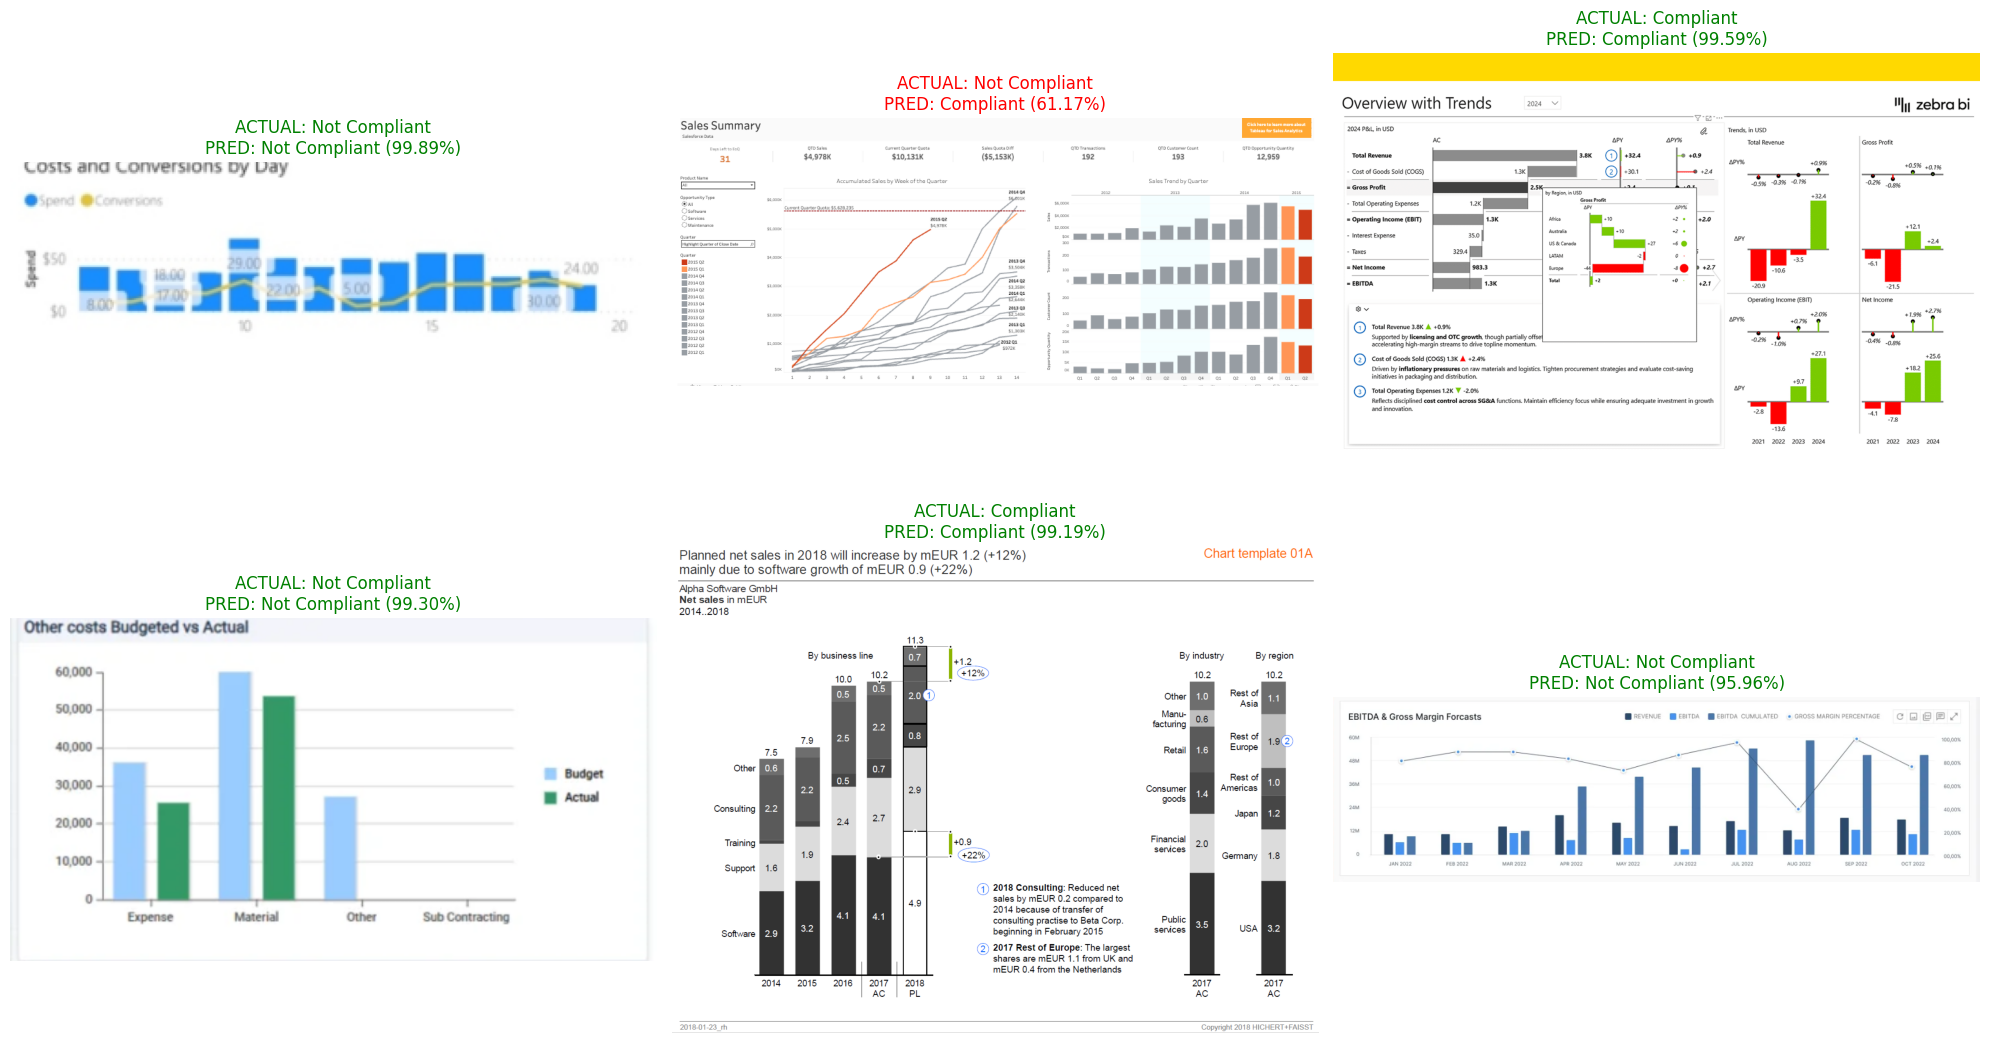

In [127]:
import random

# Get a list of all images in the test set to pick some random ones
all_test_images = []
for root, dirs, files in os.walk('split_data/test'):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_test_images.append(os.path.join(root, file))

# Pick 6 random images to display
sample_images = random.sample(all_test_images, 6)

plt.figure(figsize=(20, 12))

for i, img_path in enumerate(sample_images):
    # Run the model on the specific image
    res = model(img_path)[0]
    
    # Get details
    prob = res.probs.top1conf.item()
    pred_class = res.names[res.probs.top1]
    
    # Get actual class from the folder name
    actual_class = os.path.basename(os.path.dirname(img_path))
    
    # Plotting
    plt.subplot(2, 3, i + 1)
    plt.imshow(Image.open(img_path))
    
    # Color code: Green if correct, Red if wrong
    color = 'green' if pred_class == actual_class else 'red'
    
    plt.title(f"ACTUAL: {actual_class}\nPRED: {pred_class} ({prob:.2%})", color=color, fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

# 8. Evaluation (Confusion Matrix & Details)

Ultralytics 8.4.41  Python-3.14.2 torch-2.11.0+cpu CPU (11th Gen Intel Core i7-1165G7 @ 2.80GHz)
train: C:\Users\Melda\Desktop\IBCS-scaling-rules-check-YOLO\split_data\train... found 244 images in 2 classes  
val: C:\Users\Melda\Desktop\IBCS-scaling-rules-check-YOLO\split_data\val... found 70 images in 2 classes  
test: C:\Users\Melda\Desktop\IBCS-scaling-rules-check-YOLO\split_data\test... found 36 images in 2 classes  
test: Fast image access  (ping: 0.10.0 ms, read: 386.3110.2 MB/s, size: 55.4 KB)
test: Scanning C:\Users\Melda\Desktop\IBCS-scaling-rules-check-YOLO\split_data\test... 36 images, 0 corrupt: 100% ━━━━━━━━━━━━ 36/36 3.1Kit/s 0.0s
test: New cache created: C:\Users\Melda\Desktop\IBCS-scaling-rules-check-YOLO\split_data\test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 3/3 4.4it/s 0.7s0.5s
                   all      0.944          1
Speed: 0.0ms preprocess, 3.8ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to C:\Users\Melda\Des

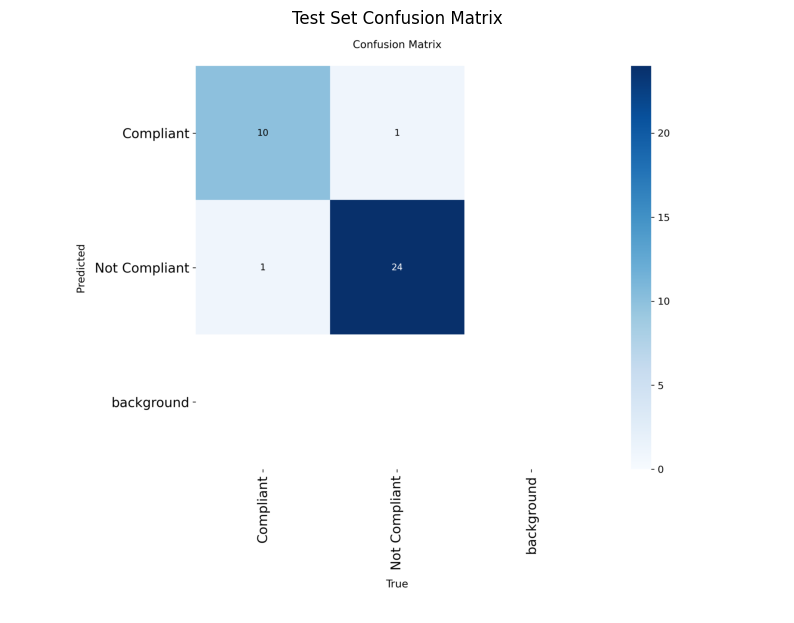

In [128]:
# The model.val() command automatically checks the 'val' or 'test' split defined in your logic
# To check the TEST set specifically:
metrics = model.val(split='test')

# Display the confusion matrix specifically for the test set
# It is saved in runs/classify/val/ (or val2, val3 depending on how many times you ran it)
import glob
cm_files = glob.glob('runs/classify/val*/confusion_matrix.png')
if cm_files:
    latest_cm = max(cm_files, key=os.path.getctime)
    plt.figure(figsize=(10, 10))
    plt.imshow(Image.open(latest_cm))
    plt.axis('off')
    plt.title("Test Set Confusion Matrix")
    plt.show()

In [129]:
class_names = model.names

stats = {}
for idx in class_names:
    stats[class_names[idx]] = {'correct': 0, 'total': 0}

for result in results:
    pred_idx = result.probs.top1
    pred_name = class_names[pred_idx]
    
    actual_path = result.path.lower()
    if 'not compliant' in actual_path:
        actual_name = 'Not Compliant'
    else:
        actual_name = 'Compliant'
    
    # 3. Update de statistieken
    if actual_name in stats:
        stats[actual_name]['total'] += 1
        if pred_name == actual_name:
            stats[actual_name]['correct'] += 1

print("--- ACCURACY PER CATEGORIE ---")
for cls_name, data in stats.items():
    if data['total'] > 0:
        acc = (data['correct'] / data['total']) * 100
        print(f"{cls_name}: {acc:.2f}% ({data['correct']}/{data['total']} goed)")
    else:
        print(f"{cls_name}: Geen testdata gevonden.")

--- ACCURACY PER CATEGORIE ---
Compliant: 90.91% (10/11 goed)
Not Compliant: 96.00% (24/25 goed)


# Combining YOLO with OCR and OpenCV (The "Next Steps")

To add some more to the classification yoou can add a tool that actually "reads" the chart data, follow these steps:
1. **YOLO for Detection:** Instead of classifying the whole image, train YOLO to detect specific objects: the Y-axis numbers and the Bars/Columns.
2. **OpenCV Preprocessing:** Use OpenCV to crop the image to the Y-axis bounding box found by YOLO. Convert it to grayscale and use cv2.threshold to make the numbers pop out against the background.
3. **OCR Data Extraction:** Pass the cropped, high-contrast Y-axis image into EasyOCR or PyTesseract. This will give you the actual strings (e.g., "0", "10", "20").
4. **Mathematical Validation:**
- Check if the OCR found a "0" at the bottom of the axis.
- If no "0" is found, the IBCS "Start at Zero" rule is broken.
- Compare the scale intervals between two different chart images to ensure they are the same (Uniform Scaling).